In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


I created a Google_connection python script to run in my Jupyter Notebook to connect to Google Colabs and to upload my
Student Performance Data Set.

The script contatins the code:


from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
    name=fn, length=len(uploaded[fn])))


The data set is temprarly stored in Colabs and will not be availible after closing the session.  See below.

 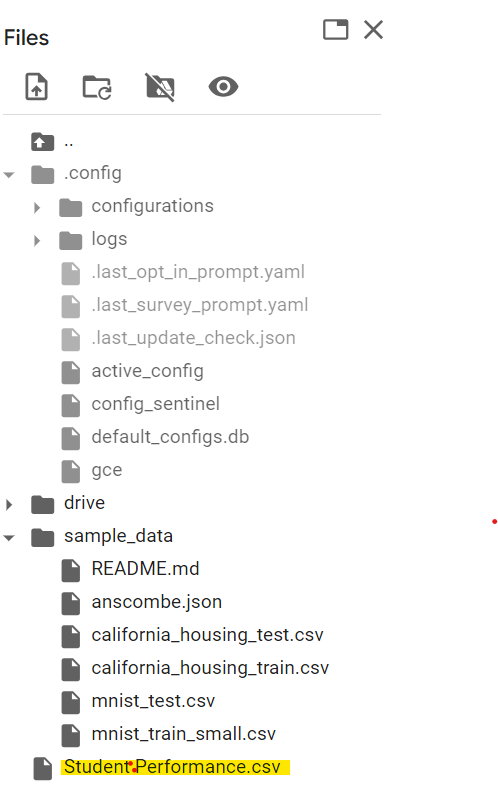

In [18]:
#Run the connection file using the %run magic commands.
%run '/content/drive/MyDrive/Google_connection.py'

Changed directory to: /content/MSSP-607/MSSP-607/MSSP-607


In [19]:
#import pandas and give it an alias
import pandas as pd


In [20]:
#Read the Student Performance.csv data set into a Pandas Dataframe.

student_performance =pd.read_csv('/content/MSSP-607/data/Student Performance Data.csv')

In [21]:
#Use the Help comannd to summarize the the Dataframe methods, modules, etc.
student_performance.head?

In [22]:
#Display the first 10 rows.
#Notice that the total score = 'math score' + 'reading score' + 'writing score'
student_performance.head(n=10) #print the first 10 rows.

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high
5,female,group B,associate's degree,standard,71,83,78,232,none,high
6,female,group B,some college,standard,88,95,92,275,completed,high
7,male,group B,some college,free/reduced,40,43,39,122,none,low
8,male,group D,high school,free/reduced,64,64,67,195,completed,medium
9,female,group B,high school,free/reduced,38,60,50,148,none,low


In [23]:
#If we change the 'math score' + 'reading score' + 'writing score', the 'total score' does not change
student_performance["reading score"] =student_performance["reading score"].apply(lambda x: x-2) #Changes the reading score by subtracting 2
#from the current values in the series.

print(student_performance["reading score"])

0      70
1      88
2      93
3      55
4      76
       ..
995    97
996    53
997    69
998    76
999    84
Name: reading score, Length: 1000, dtype: int64


In [24]:
#The 'total score is now invalid.  Make sure when you change a series, that you update dependent series.
student_performance.head()

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,70,74,218,none,medium
1,female,group C,some college,standard,69,88,88,247,completed,high
2,female,group B,master's degree,standard,90,93,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,55,44,148,none,low
4,male,group C,some college,standard,76,76,75,229,none,high


In [25]:
#Correct the 'total score' series
student_performance["total score"] = student_performance["math score"]+student_performance["reading score"]+student_performance["writing score"]
student_performance

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,70,74,216,none,medium
1,female,group C,some college,standard,69,88,88,245,completed,high
2,female,group B,master's degree,standard,90,93,93,276,none,high
3,male,group A,associate's degree,free/reduced,47,55,44,146,none,low
4,male,group C,some college,standard,76,76,75,227,none,high
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,88,97,95,280,completed,high
996,male,group C,high school,free/reduced,62,53,55,170,none,medium
997,female,group C,high school,free/reduced,59,69,65,193,completed,medium
998,female,group D,some college,standard,68,76,77,221,completed,high


In [26]:
#Or re-read the original Student Performance CSV file.
student_performance =pd.read_csv('/content/MSSP-607/data/Student Performance Data.csv')
student_performance.head(n=10)

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium
1,female,group C,some college,standard,69,90,88,247,completed,high
2,female,group B,master's degree,standard,90,95,93,278,none,high
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low
4,male,group C,some college,standard,76,78,75,229,none,high
5,female,group B,associate's degree,standard,71,83,78,232,none,high
6,female,group B,some college,standard,88,95,92,275,completed,high
7,male,group B,some college,free/reduced,40,43,39,122,none,low
8,male,group D,high school,free/reduced,64,64,67,195,completed,medium
9,female,group B,high school,free/reduced,38,60,50,148,none,low


In [27]:
#We can add a series as well using the lambda function.
#Add a 'percentage' series to the dataframe assuming the total for each test is 100
student_performance = student_performance.assign(percentage = lambda x: (x['total score'] /300 * 100))
student_performance.head() #We now have a metric/grade to assign to a student.

,gender,race/ethnicity,parental level of education,lunch,math score,reading score,writing score,total score,test preparation course,admission prospect,percentage
0,female,group B,bachelor's degree,standard,72,72,74,218,none,medium,72.666667
1,female,group C,some college,standard,69,90,88,247,completed,high,82.333333
2,female,group B,master's degree,standard,90,95,93,278,none,high,92.666667
3,male,group A,associate's degree,free/reduced,47,57,44,148,none,low,49.333333
4,male,group C,some college,standard,76,78,75,229,none,high,76.333333


In [28]:
student_performance.describe()

,math score,reading score,writing score,total score,percentage
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,203.312000,67.770667
std,15.16308,14.600192,15.195657,42.771978,14.257326
min,0.00000,17.000000,10.000000,27.000000,9.000000
25%,57.00000,59.000000,57.750000,175.000000,58.333333
50%,66.00000,70.000000,69.000000,205.000000,68.333333
75%,77.00000,79.000000,79.000000,233.000000,77.666667
max,100.00000,100.000000,100.000000,300.000000,100.000000


In [29]:
#Summarize the 'admission prospect'
student_performance.groupby(['admission prospect'])['total score'].mean(numeric_only=True)

,total score
admission prospect,
high,246.550562
low,139.514793
medium,193.604211


In [30]:
#Grouping by gender we see that females perform better than males.
#At this point, we can not conclude that this is statistacally significant
#unless we due a statistical test.  We will do that later in class.
student_performance.groupby('gender').mean(numeric_only=True)


,math score,reading score,writing score,total score,percentage
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


In [31]:
#Let's see how the lunch program impacts student's performance.
student_performance.groupby(['gender','lunch'])['total score'].mean(numeric_only=True)


gender  lunch       
female  free/reduced    189.645503
        standard        219.659574
male    free/reduced    183.126506
        standard        205.069620
Name: total score, dtype: float64

**QUESTION 1: Does parental education influence test score outcomes, and if so, how much?**

In [32]:
#It would appear that 'parental level of education' influences student performance
student_performance.groupby('parental level of education').mean(numeric_only=True)

,math score,reading score,writing score,total score,percentage
parental level of education,,,,,
associate's degree,67.882883,70.927928,69.896396,208.707207,69.569069
bachelor's degree,69.389831,73.000000,73.381356,215.771186,71.923729
high school,62.137755,64.704082,62.448980,189.290816,63.096939
master's degree,69.745763,75.372881,75.677966,220.796610,73.598870
some college,67.128319,69.460177,68.840708,205.429204,68.476401
some high school,63.497207,66.938547,64.888268,195.324022,65.108007


**Question 2: Which group performs best as classified as an admissions prospect?**

In [33]:
#It would appear that Group E performs better than other groups.
student_performance.groupby(['admission prospect','race/ethnicity'])['total score'].mean(numeric_only=True)

admission prospect  race/ethnicity
high                group A           248.523810
                    group B           244.131148
                    group C           245.105769
                    group D           245.158416
                    group E           252.304348
low                 group A           142.518519
                    group B           133.625000
                    group C           137.163265
                    group D           143.142857
                    group E           147.444444
medium              group A           189.073171
                    group B           191.910112
                    group C           192.969880
                    group D           195.269841
                    group E           197.981132
Name: total score, dtype: float64

**QUESTION 3: How does each gender perform in total score categorized by test preparation course completed or not?**

In [34]:
student_performance.groupby(['gender','test preparation course'])['total score'].mean(numeric_only=True)

gender  test preparation course
female  completed                  223.364130
        none                       200.634731
male    completed                  212.344828
        none                       189.133117
Name: total score, dtype: float64

**QUESTION 4: Are the differences between race/ethnicity? Explain your analysis**

In [35]:
#Let's group by 'race/ethnicity' to see how the groups compare
#It would appear that there is a significant difference between the groups.
#Again, we would need a statistical test to confirm.
student_performance.groupby('race/ethnicity').mean(numeric_only=True)

,math score,reading score,writing score,total score,percentage
race/ethnicity,,,,,
group A,61.629213,64.674157,62.674157,188.977528,62.992509
group B,63.452632,67.352632,65.600000,196.405263,65.468421
group C,64.463950,69.103448,67.827586,201.394984,67.131661
group D,67.362595,70.030534,70.145038,207.538168,69.179389
group E,73.821429,73.028571,71.407143,218.257143,72.752381


**QUESTION 5: Is the sample biased?  Explain your analysis.**

In [36]:
#Let's compare the distribution by gender to see if the sample is biased; at least from a gender standpoint.
#According to the U.S. Census Bereau, in 2021, the population of the United States was 331,893,745 people with
#Males making up 49.5% and Females making up 50.5% of the population; +/- 0.1 margin of error.
#It would apear that the sample is biased slightly towards females from a gender standpoint.  We would need to check 'race/ethnicity'
#or other atttributes as well if we had the data.

#Considering IPEDS from the National Center for Educational Statistics, the total number of students enrolled in higher education
#is 19,036,612 with 7,909,565 (41.5%) being male and 11,127,047 being female (58%).  The answer to bias is it depends.
#We need to specifically test for bias.

#See: https://scikit-learn.org/stable/auto_examples/ensemble/plot_bias_variance.html

#See: https://www.law.upenn.edu/live/files/11569-field-guide-to-address-bias-in-datasets

#See: https://data.census.gov/table/ACSDP1Y2021.DP05?q=male+female+ratio&t=Age+and+Sex&g=010XX00US&y=2021

gender_group = student_performance.groupby('gender')['total score'].agg(total='count')
gender_group['percentage'] = (gender_group['total'] / gender_group['total'].sum()) * 100
gender_group

,total,percentage
gender,,
female,518,51.8
male,482,48.2
